In the growing presence of AI in our world, from Fortune 500 companies adopting their own AI chatbots, to automated fast food drive-through workers, to discussions about the millions of people who may be laid off, there are clear shifts in the ways our everyday interactions and workflows may be affected by this emerging technology. Cars are no exception.

Founded in 2009 as a Google Self Driving Car Project, Waymo is slowly emerging as a new possibility for riders. Autonomous vehicles themselves are not new, but Waymo’s rapid commercialization and implementation in some of America’s largest West Coast cities, such as San Francisco and Los Angeles, opens the door to a future where autonomous vehicles might become a normal part of everyday life. Now, the company is looking to expand to the East Coast, with pilots in Washington D.C., New York City, and Philadelphia.

With broader discussions surrounding both the cultural and safety implications of implementing Waymo, it raises an important question: How will Waymo affect vehicular and pedestrian safety in the future, and more importantly, is there even a market for Waymo in Philadelphia? To explore that question, I analyzed 19 years of crash data from PennDOT in Philadelphia and compared those patterns with what we know about how Waymo vehicles perform on the road.

<img src="photo1.png" width="800">

## The Safety Case for Waymo

When thinking about Waymo’s introduction to Philadelphia and its potential safety implications, it is important to first look at Waymo’s own performance data. According to a recently published journal article by the company, Waymo analyzed 127 million miles of trips taken by fully autonomous robotaxis and compared those results to human driving benchmarks. The findings were significant.

Compared to the average human driver across the same distance in operating cities, Waymo experienced:

- 90 percent fewer crashes involving serious injuries

- 81 percent fewer injury causing crashes

- 92 percent fewer pedestrian crashes with injuries

- 83 percent fewer cyclist crashes with injuries

- 80 percent fewer motorcycle crashes with injuries

These numbers stand out because traffic crashes remain one of the most persistent public safety problems in the United States.

## *More than 39,000 Americans died in vehicle crashes last year, which is more than deaths from homicide, plane crashes, and natural disasters combined. Traffic collisions are also the second leading cause of death for children and young adults.*

In other words, the potential stakes are enormous. If autonomous vehicles can significantly reduce crashes, they could reshape road safety in ways that feel closer to a public health breakthrough than a transportation upgrade.

Of course, the technology still has regulatory hurdles. In Pennsylvania, companies must receive approval from PennDOT before offering commercial rides. That process requires companies to demonstrate cybersecurity protections, store operational driving data, and prove that vehicles can safely respond to emergency vehicles.

But assuming those requirements are eventually met, with access to 19 years of vehicle crash data from PennDOT, I analyzed trends across nearly two decades of vehicle accidents in Philadelphia to see whether any patterns emerge. Would Waymo help reduce crashes in the city, or could it introduce new risks?

## Looking at Two Decades of Philadelphia Crash Data

To understand how autonomous vehicles might affect safety in the city, I started by examining nearly two decades of crash data from PennDOT. When plotting the number of crashes per year between 2005 and 2022, one trend stands out fairly quickly: Overall crashes in Philadelphia have gradually declined over time, falling by roughly 8,000 incidents during that period.

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import camelot
import calendar
import re
import matplotlib.pyplot as plt
from shapely.geometry import Point
import shapely
import json

In [2]:
crash_data = pd.read_csv('data/PDOT_crash_data_2005_2024.csv', low_memory=False)

In [3]:
data_dictionary = pd.read_csv('data/data_dictionary.csv')

In [4]:
philly_gdf = gpd.read_file('data/philadelphia_zip_boundaries.geojson')

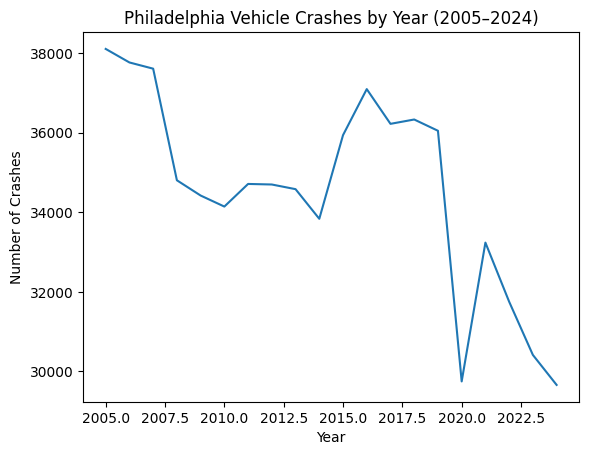

In [5]:
crashes_by_year = crash_data.groupby("CRASH_YEAR")["CRN"].count()

plt.figure()
crashes_by_year.plot()
plt.title("Philadelphia Vehicle Crashes by Year (2005–2024)")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")
plt.show()

That is encouraging on its own becuase it strongly suggests that road safety has been improving through better infrastructure, enforcement, and driver awareness. But it also raises an interesting question: if crashes are already decreasing, how much additional impact could autonomous vehicles realistically have?

To get a clearer picture, I looked deeper into the data to understand when crashes happen, what kinds of crashes occur, and where they tend to concentrate.

## When Do Most Crashes Happen?

It is widely known that most vehicle collisions are caused by human error rather than mechanical failure, but I wanted to examine this idea more closely using the available data.

I began by analyzing two variables: what times of day crashes most frequently occur, and which months experience the highest number of incidents.

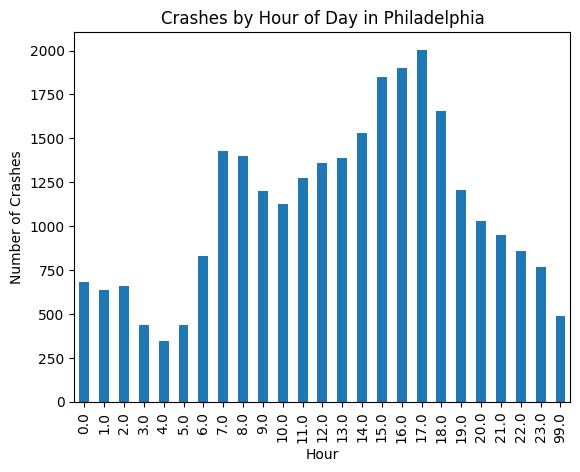

In [6]:
crashes_by_hour = crash_data.groupby("HOUR_OF_DAY")["CRN"].count()

plt.figure()
crashes_by_hour.plot(kind="bar")
plt.title("Crashes by Hour of Day in Philadelphia")
plt.xlabel("Hour")
plt.ylabel("Number of Crashes")
plt.show()

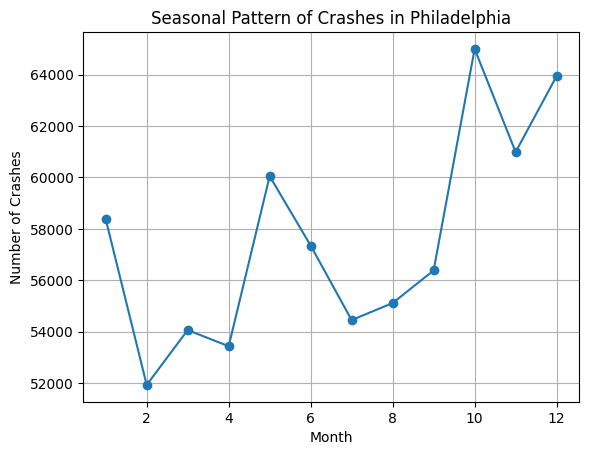

In [7]:
crashes_by_month = crash_data.groupby("CRASH_MONTH")["CRN"].count().sort_index()

plt.figure()

plt.plot(crashes_by_month.index, crashes_by_month.values, marker="o")

plt.title("Seasonal Pattern of Crashes in Philadelphia")
plt.xlabel("Month")
plt.ylabel("Number of Crashes")

plt.grid(True)

plt.show()

The results showed that crashes most commonly occur around 15:00 to 17:00, or roughly 3 p.m. to 5 p.m. The data also shows higher crash rates during the summer and winter months.

Several factors could contribute to these patterns. Late afternoon hours often coincide with rush hour traffic as people commute home from work, while winter months may involve icy roads or reduced visibility. Summer months may see increased traffic and pedestrian activity. While the dataset alone cannot determine exact causes, these patterns provide useful clues.

When considering how Waymo might perform under these conditions, there are both potential strengths and challenges.

According to the Philly Voice, Waymo began testing autonomous vehicles in Philadelphia this December to understand how they perform in colder environments. These tests aim to evaluate charging performance in freezing temperatures and how vehicles respond to snow conditions. This presents a new challenge for the company, since many of their most successful deployments have taken place in West Coast cities that rarely experience snow.

In terms of time of day, however, Waymo may have an advantage. Autonomous vehicles do not experience fatigue or distraction in the same way human drivers do. The main question becomes how Waymo vehicles would interact with human drivers during these busy rush hour periods, especially if autonomous vehicles remain a minority on the road.

But these are only preliminary observations, so I looked further into the types of crashes occurring in Philadelphia.

## What Types of Crashes Are These?

Next, I analyzed the most common types of crashes in Philadelphia, focusing on both location and vehicle involvement.

I first examined PennDOT data related to intersection crashes. Fortunately, intersection related crashes make up a relatively small portion of incidents in Philadelphia. With the introduction of autonomous vehicles, this number could potentially decrease even further.

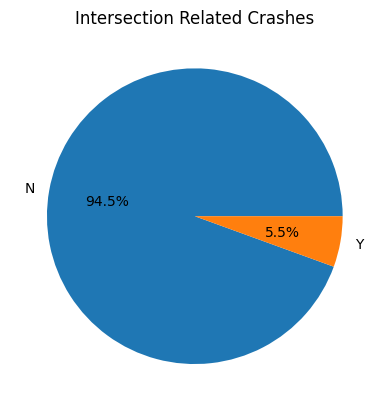

In [8]:
intersection_counts = crash_data["INTERSECTION_RELATED"].value_counts()

plt.figure()
intersection_counts.plot(kind="pie", autopct="%1.1f%%")
plt.title("Intersection Related Crashes")
plt.ylabel("")
plt.show()

According to an Understanding AI article, Waymo vehicles were involved in 45 crashes over a six month period. However, a large majority of those crashes were clearly not the fault of the Waymo vehicle. In 24 cases, the Waymo vehicle was not moving at all, and in 7 cases it was rear ended by another vehicle. Across those incidents, 41 crashes involved some form of driver error, either from human drivers or from the autonomous system.

While this data generally points toward strong performance from Waymo vehicles, I also wanted to examine what types of crashes are most common in Philadelphia specifically.

Looking deeper into the data, pedestrian related crashes and crashes involving heavy trucks appear to be among the most common types.

In [14]:
vehicle_types = {
    "Bus": crash_data["BUS_COUNT"].sum(),
    "Bicycle": crash_data["BICYCLE_COUNT"].sum(),
    "Pedestrian": crash_data["PED_COUNT"].sum(),
    "Motorcycle": crash_data["MOTORCYCLE_COUNT"].sum(),
    "Heavy Truck": crash_data["HEAVY_TRUCK_COUNT"].sum()
}

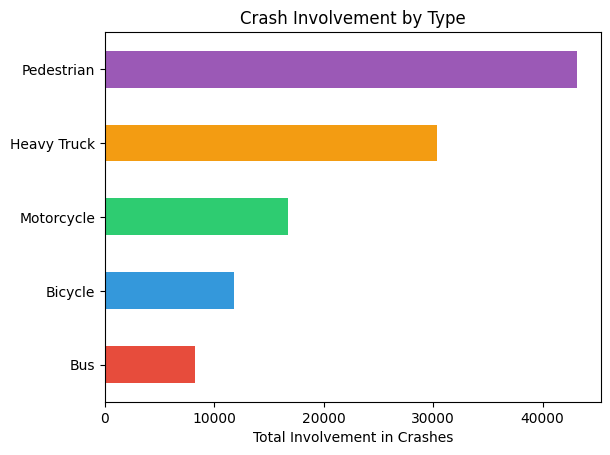

In [15]:
colors = ["#e74c3c", "#3498db", "#2ecc71", "#f39c12", "#9b59b6"]

vehicle_df = pd.Series(vehicle_types)
plt.figure()
vehicle_df.sort_values().plot(kind="barh", color=colors)
plt.title("Crash Involvement by Type")
plt.xlabel("Total Involvement in Crashes")
plt.show()

For Waymo, this could represent either a challenge or an opportunity. The company has recently faced criticism regarding whether its detection systems can reliably identify small children or animals such as outdoor cats. These issues are especially heightened after a Waymo killed a beloved San Francisco bodega cat named Kit Kat in October 2025. If these detection issues remain unresolved, pedestrian and animal safety could become a concern, especially since pedestrians already represent one of the most common crash types in Philadelphia. If these systems improve, however, autonomous vehicles could potentially reduce those incidents.

Importantly, within these crashes, I also wanted to see how many were within school zones.

In [11]:
school_zone_total = (crash_data["SCH_ZONE_IND"] == "Y").sum()

total_crashes = crash_data["CRN"].count()

comparison = {
    "School Zone Crashes": school_zone_total,
    "All Other Crashes": total_crashes - school_zone_total
}

comparison_df = pd.Series(comparison)

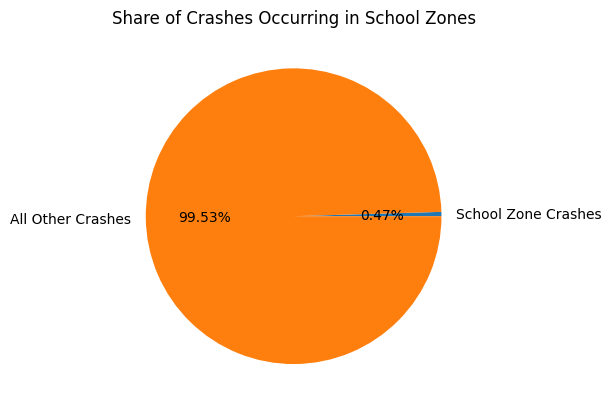

In [12]:
plt.figure()

comparison_df.plot(kind="pie", autopct="%1.2f%%")

plt.title("Share of Crashes Occurring in School Zones")
plt.ylabel("")

plt.show()

Only 0.5 percent of crashes in Philadelphia occur in school zones, which is surprisingly low. This statistic is important because Waymo has additionally been criticized for failing to demonstrate proper behavior when stopping for school buses during student drop offs. Situations like these pose serious safety risks for children crossing the street. If autonomous vehicles are introduced widely without addressing these issues, even this small percentage could increase.

<img src="waymoschoolbus.png" width="800">

## The Big Picture

Finally, I looked at the geographic distribution of crashes across Philadelphia to see where incidents occur most frequently. The results highlight higher crash concentrations in densely populated areas such as Center City and Northeast Philadelphia, while more suburban areas experience fewer crashes overall.

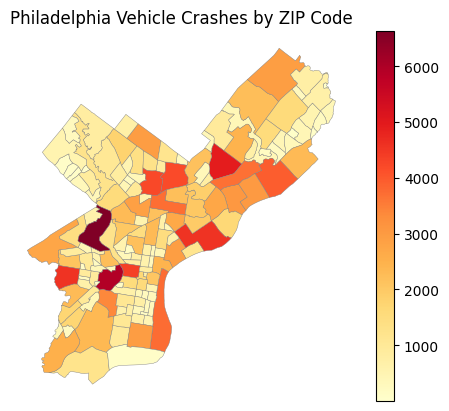

In [13]:
crash_df = pd.read_csv("data/PDOT_crash_data_2005_2024.csv", low_memory=False)
zip_gdf = gpd.read_file("data/philadelphia_zip_boundaries.geojson")

clean_df = crash_df.dropna(subset=["DEC_LATITUDE", "DEC_LONGITUDE"])
crash_gdf = gpd.GeoDataFrame(
    clean_df,
    geometry=gpd.points_from_xy(clean_df["DEC_LONGITUDE"], clean_df["DEC_LATITUDE"]),
    crs="EPSG:4326"
)

zip_col = zip_gdf.columns[0]
counts = gpd.sjoin(crash_gdf, zip_gdf, how="inner", predicate="within").groupby(zip_col).size()
zip_gdf["crash_count"] = zip_gdf[zip_col].map(counts).fillna(0)

zip_gdf.plot(column="crash_count", cmap="YlOrRd", legend=True, edgecolor="gray", linewidth=0.3)
plt.title("Philadelphia Vehicle Crashes by ZIP Code")
plt.axis("off")
plt.savefig("philly_crashes.png", dpi=150, bbox_inches="tight")
plt.show()

Based on the data I analyzed and the reporting on Waymo’s capabilities, one conclusion becomes fairly clear: Many crashes in Philadelphia are closely linked to human behavior, which is the core problem autonomous vehicles are designed to address.

Simultaneously, Philadelphia does not appear to have any extreme weather or geographic conditions that would make it uniquely difficult for autonomous vehicles compared to other major cities. Current statistics from Waymo deployments also suggest that autonomous vehicles can reduce crash rates in urban environments.

However, safety statistics alone will not determine whether the technology succeeds, public trust will likely matter just as much.

Philadelphia has a complicated history with robots. In 2015, the hitchhiking robot HitchBOT successfully traveled through several cities before being destroyed shortly after arriving in Philadelphia. Local reactions to Waymo already reflect a similar mix of curiosity and skepticism. Some residents welcome the idea of autonomous vehicles because of the city’s reputation for aggressive driving. Others worry about allowing experimental technology onto crowded streets.

And it is not just Philly that have had mixed reactions to the vehicles. According to reporting from WHYY, some critics question how autonomous vehicles should respond in unpredictable situations, such as if a passenger becomes caught in a protest or civil unrest. In Los Angeles this past summer, protesters even set several Waymo vehicles on fire.

<img src="waymofire.png" width="700">

There are also environmental and economic considerations. While Waymo vehicles themselves are electric, advanced AI systems require significant electricity and computing power. As AI adoption grows more broadly, questions about energy usage and sustainability will likely become more prominent.

Labor groups have also raised concerns about how driverless vehicles could affect jobs in transportation. And importantly, cost could be another barrier. Waymo rides tend to be more expensive than Uber or Lyft in many cities. In a place where many residents rely heavily on public transit and where SEPTA faces funding challenges, affordability will likely influence whether people adopt the service.

## The Bigger Picture

Autonomous vehicles represent one of the most ambitious attempts to apply artificial intelligence to everyday life. Some experts believe the technology could dramatically change road safety. Neurosurgeon Jonathan Slotkin wrote in a New York Times opinion piece that if Waymo’s results scale nationwide, autonomous vehicles could eventually eliminate traffic deaths as a major cause of mortality in the United States.

At the same time, concerns remain about reliability, energy use, pricing, and public acceptance. Philadelphia may be an especially revealing place to test those questions. The city has dense traffic, unpredictable driving habits, winter weather, and residents who rarely hesitate to share their opinions about new technology.

The crash data suggests that autonomous vehicles could address several of the patterns that currently lead to collisions in Philadelphia. Whether residents are willing to trust those vehicles enough to ride in them is another question entirely.

<img src="hitchbot.png" width="550">

Ultimately, the future of Waymo in Philadelphia is still uncertain. If the company can address its technical challenges, improve public trust, develop sustainable energy practices, and offer affordable pricing, the service could become widely adopted.

For now, however, those questions remain unresolved. And judging by the early reactions online, where some residents are already complaining about seeing Waymo vehicles in Center City, Philadelphia’s response to driverless cars may be complicated.